In [2]:
import os,sys
import numpy as np
import pandas as pd
import scanpy as sc
from src import PATH

In [47]:
sc.set_figure_params(figsize=(4,3), dpi=80, frameon=False)

# **QC**

In [50]:
mul_adata = sc.read_h5ad("/home/wergillius/Project/diffuse_differentiate/data/Perturb_sci/multi_modal_count_Jan13.h5ad")

In [51]:
mul_adata.var = mul_adata.var.set_index("Gene_Symbol")

In [52]:
# change datatype to normalize
mul_adata.X = mul_adata.X.astype('float64')

### basic filtering

In [53]:
sc.pp.filter_cells(mul_adata, min_genes=500)
sc.pp.filter_genes(mul_adata, min_cells=20)

In [54]:
mul_adata.var['mt'] = mul_adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(mul_adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

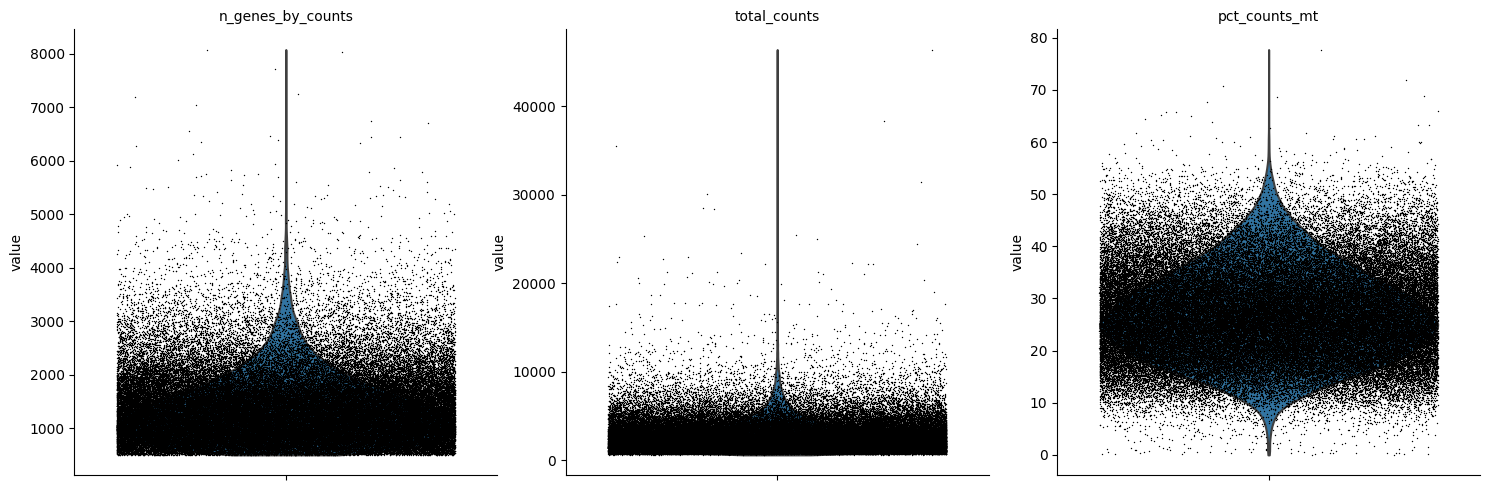

In [55]:
sc.pl.violin(mul_adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

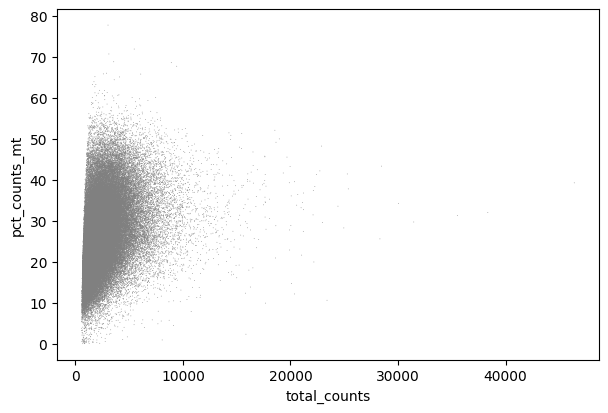

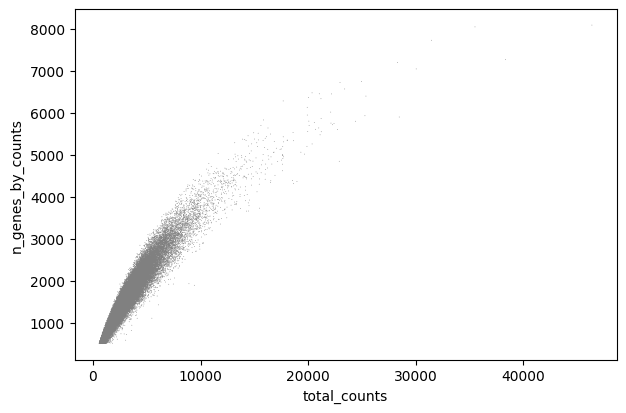

In [56]:
sc.pl.scatter(mul_adata, x='total_counts', y='pct_counts_mt')
sc.pl.scatter(mul_adata, x='total_counts', y='n_genes_by_counts')

In [59]:
filter_adata = mul_adata[mul_adata.obs.n_genes_by_counts < 6000, :]
filter_adata = filter_adata[filter_adata.obs.pct_counts_mt < 50, :]

In [62]:
filter_adata.write_h5ad("/home/wergillius/Project/diffuse_differentiate/data/Perturb_sci/multi_modal_filtered_Jan16.h5ad")

## normalize and visualize

In [63]:
mul_adata = filter_adata

In [65]:
sc.pp.normalize_per_cell(mul_adata, counts_per_cell_after=10000, layers='all')
sc.pp.log1p(mul_adata)

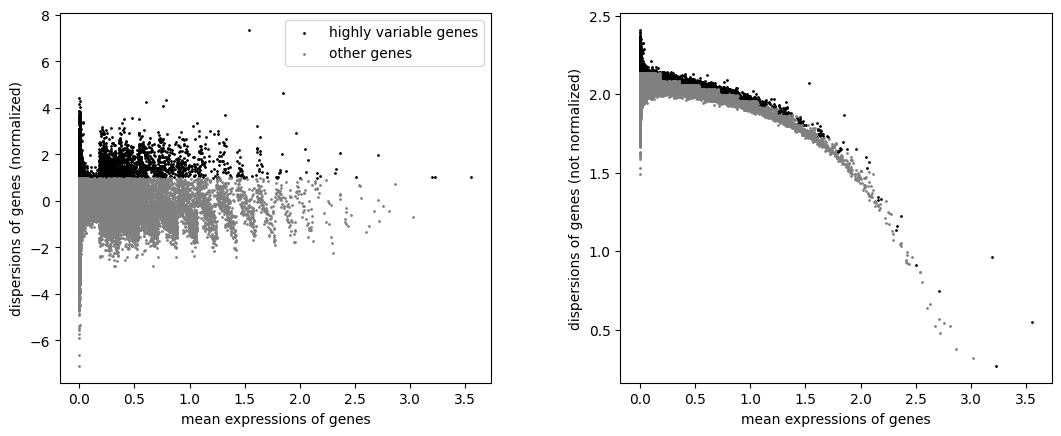

In [66]:
sc.pp.highly_variable_genes(mul_adata, n_top_genes=4000)
sc.pl.highly_variable_genes(mul_adata)

In [67]:
# pca and visualization

In [68]:
mul_adata.raw = mul_adata
mul_adata = mul_adata[:, mul_adata.var.highly_variable]
mul_adata

View of AnnData object with n_obs × n_vars = 90761 × 4000
    obs: 'UMI_counts', 'nascent_UMI_counts', 'nascent_ratio', 'target', 'target_genes', 'gRNA_UMI_counts', 'MT_ratio', 'nascent_MT_ratio', 'Cell_cycle_phase', 'whole_exon_ratio', 'new_exon_ratio', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    obsm: 'ontarget_sgRNA'
    layers: 'Count_nascent_tx', 'Count_whole_tx'

In [69]:
mul_adata = mul_adata[:, mul_adata.var.highly_variable]
mul_adata

View of AnnData object with n_obs × n_vars = 90761 × 4000
    obs: 'UMI_counts', 'nascent_UMI_counts', 'nascent_ratio', 'target', 'target_genes', 'gRNA_UMI_counts', 'MT_ratio', 'nascent_MT_ratio', 'Cell_cycle_phase', 'whole_exon_ratio', 'new_exon_ratio', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    obsm: 'ontarget_sgRNA'
    layers: 'Count_nascent_tx', 'Count_whole_tx'

In [71]:
sc.pp.regress_out(mul_adata, ['total_counts', 'pct_counts_mt'])

In [72]:
sc.pp.scale(mul_adata, max_value=10)

In [77]:
mul_adata

AnnData object with n_obs × n_vars = 90761 × 4000
    obs: 'UMI_counts', 'nascent_UMI_counts', 'nascent_ratio', 'target', 'target_genes', 'gRNA_UMI_counts', 'MT_ratio', 'nascent_MT_ratio', 'Cell_cycle_phase', 'whole_exon_ratio', 'new_exon_ratio', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'ontarget_sgRNA', 'X_pca'
    varm: 'PCs'
    layers: 'Count_nascent_tx', 'Count_whole_tx'

In [73]:
mul_adata.write_h5ad("/home/wergillius/Project/diffuse_differentiate/data/Perturb_sci/multi_modal_filtered_Jan16.h5ad")

## PCA

In [74]:
sc.tl.pca(mul_adata, svd_solver='arpack')

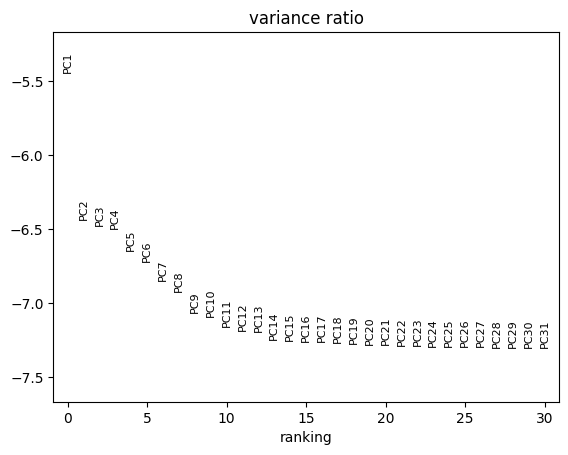

In [75]:
sc.pl.pca_variance_ratio(mul_adata, log=True)

In [79]:
sc.pp.neighbors(mul_adata, n_neighbors=550)

In [ ]:
sc.tl.umap(mul_adata)

In [85]:
mul_adata.write_h5ad("/home/wergillius/Project/diffuse_differentiate/data/Perturb_sci/multi_modal_filtered_Jan16.h5ad")

# **PAGA**

In [84]:
mul_adata = sc.read_h5ad("/home/wergillius/Project/diffuse_differentiate/data/Perturb_sci/multi_modal_filtered_Jan16.h5ad")

In [85]:
mul_adata

AnnData object with n_obs × n_vars = 90761 × 4000
    obs: 'UMI_counts', 'nascent_UMI_counts', 'nascent_ratio', 'target', 'target_genes', 'gRNA_UMI_counts', 'MT_ratio', 'nascent_MT_ratio', 'Cell_cycle_phase', 'whole_exon_ratio', 'new_exon_ratio', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'ontarget_sgRNA'
    varm: 'PCs'
    layers: 'Count_nascent_tx', 'Count_whole_tx'
    obsp: 'connectivities', 'distances'

In [3]:
mul_adata.obs.target.nunique()

489

In [4]:
sc.pp.neighbors(mul_adata, n_neighbors=50)
sc.tl.leiden(mul_adata, random_state = 0)

/home/wergillius/.local/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


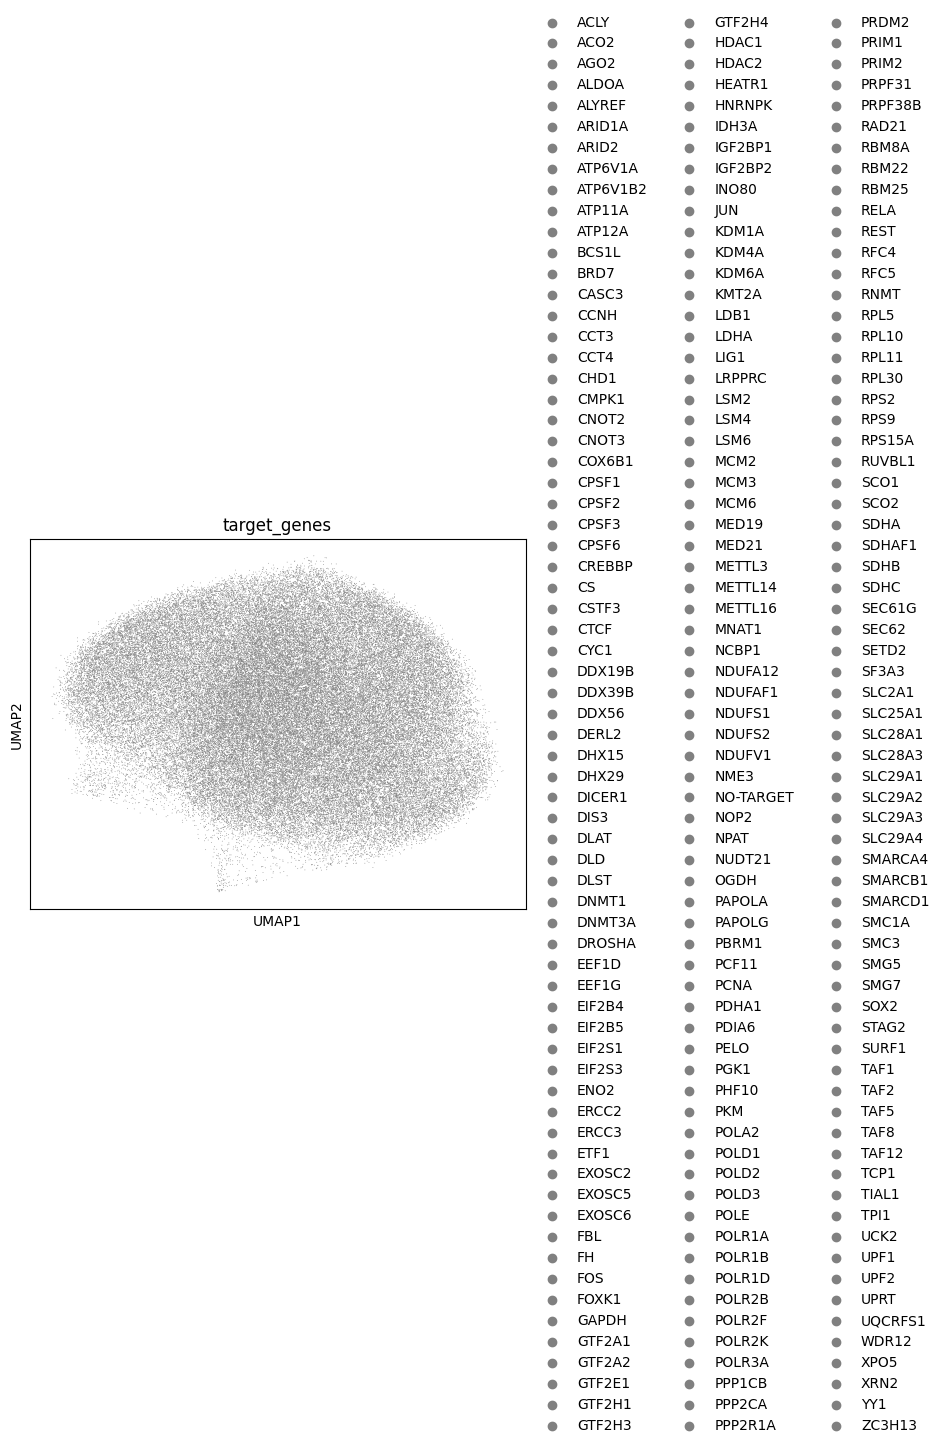

In [5]:
sc.pl.umap(mul_adata, color=['target_genes'])

In [7]:
sc.tl.leiden(mul_adata, resolution=0.8)

In [8]:
sc.tl.paga(mul_adata)
sc.pl.paga(mul_adata, plot=False)  # remove `plot=False` if you want to see the coarse-grained graph
sc.tl.umap(mul_adata, init_pos='paga')

In [25]:
mul_adata.write_h5ad("/home/wergillius/Project/diffuse_differentiate/data/Perturb_sci/Preprocessed_Apr11.h5ad")

# **prepare the data for sampling**

In [ ]:
# TODO: prepare the `unique_token_dict`

In [41]:
with open('target_genes.txt', 'w') as f:
    for gene in mul_adata.obs.target_genes.cat.categories:
        f.write(gene+"\n")

In [40]:
with open('targets.txt', 'w') as f:
    for gene in mul_adata.obs.target.cat.categories:
        f.write(gene+"\n")

In [42]:
unique_token_dict = {g:i for i, g in enumerate(mul_adata.obs.target_genes.cat.categories)}

mul_adata.uns['unique_token_dict'] = unique_token_dict

count condition distribution

## filter out the dettached cells

/home/wergillius/.local/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


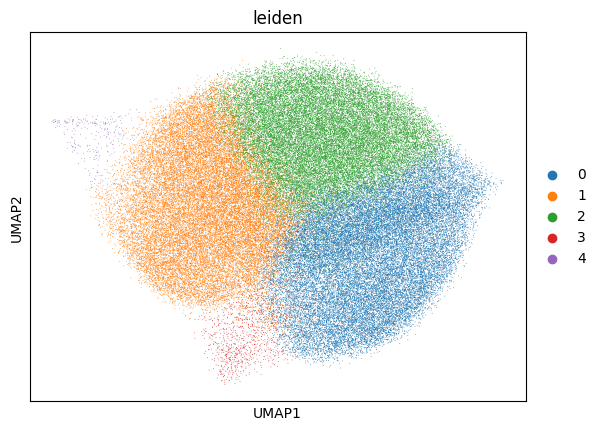

In [76]:
sc.pl.umap(mul_adata, color=['leiden'])

In [80]:
pure_cluster = ['0', '1', '2']
mul_adata_pure = mul_adata[mul_adata.obs.query("`leiden` in @pure_cluster").index].copy()

# **find root**

In [33]:
try:
#  if adata not loaded
    mul_adata_pure
except:
    mul_adata_pure = sc.read_h5ad("/home/wergillius/Project/diffuse_differentiate/data/Perturb_sci/d_preprocessed_Apr11.h5ad")

In [5]:
# find negative control (NC)
"NO-TARGET" in mul_adata.obs['target_genes'].values

True

In [34]:
mul_adata_pure.obs['is_control'] = mul_adata_pure.obs['target_genes'].values == "NO-TARGET"
mul_adata_pure.obs['is_control'] = mul_adata_pure.obs['is_control'].astype('category')

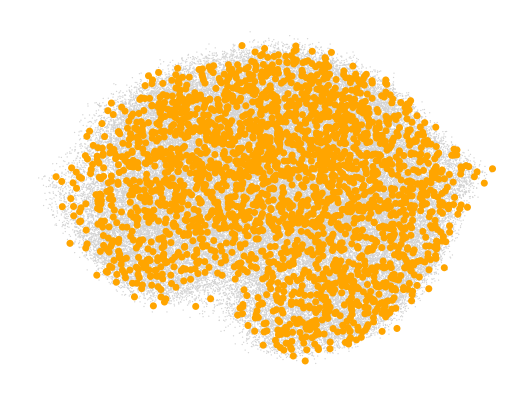

In [60]:
# check the distribution of control cell
control_cells = mul_adata_pure[mul_adata_pure.obs.is_control==True].copy()

fig = sc.pl.umap(mul_adata_pure, show=False, return_fig=True)
sc.pl.umap(control_cells, size=40, na_color='orange', ax=fig.gca())

In [83]:
control_cells.shape

(2522, 4000)

<font size=4 color='skyblue'> check the density of NC cells</font>

In [67]:
import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats

<font size=4 color='darkgreen'>All cells

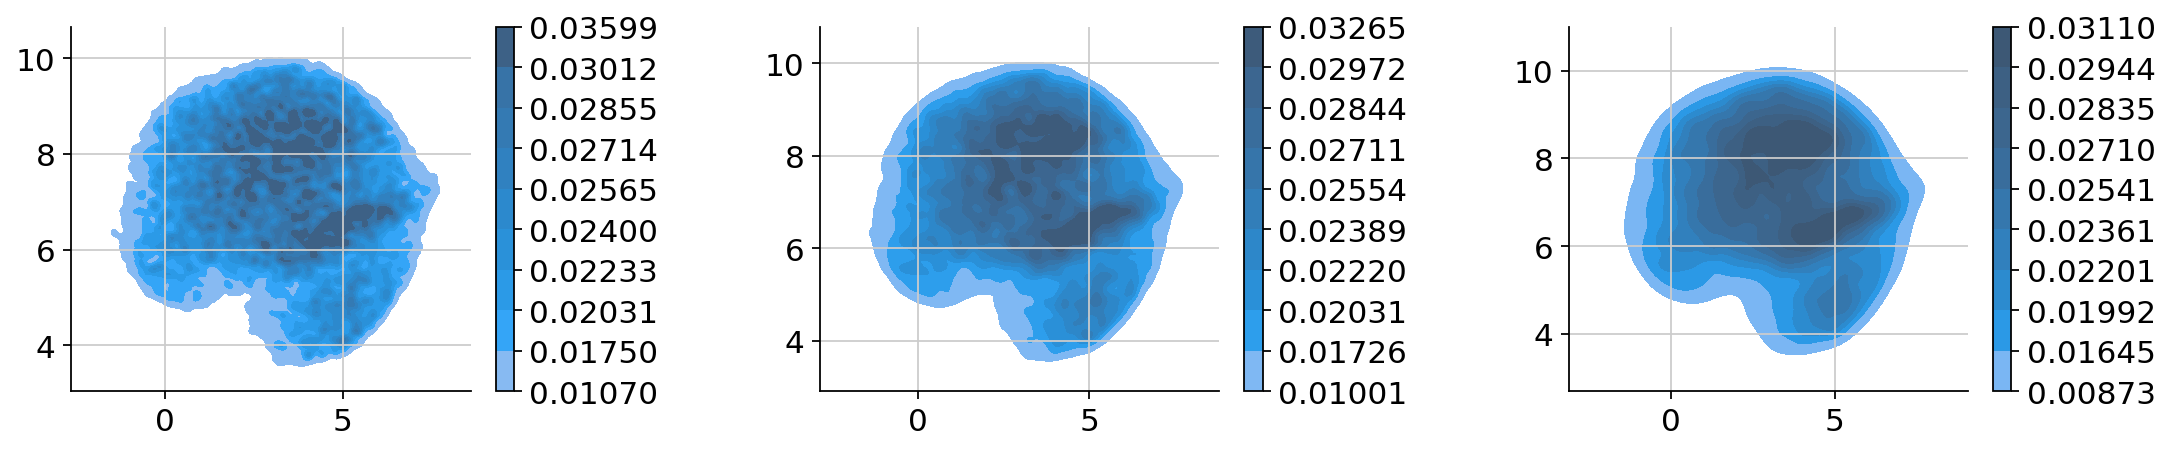

In [80]:
ucoords = mul_adata_pure.obsm['X_umap']

fig, axs = plt.subplots(1,3, figsize=(16,3), gridspec_kw={'wspace':0.5})

for i, bw in enumerate([0.3, 0.5, 0.8]):
    sns.kdeplot(x=ucoords[:,0], y=ucoords[:,1], fill=True, cbar=True, bw_adjust=bw, ax=axs[i])
    sns.despine(ax=axs[i])

<font size=4 color='darkgreen'>control cells

In [61]:
umap_coords = control_cells.obsm['X_umap']
print(umap_coords.shape)

(2522, 2)


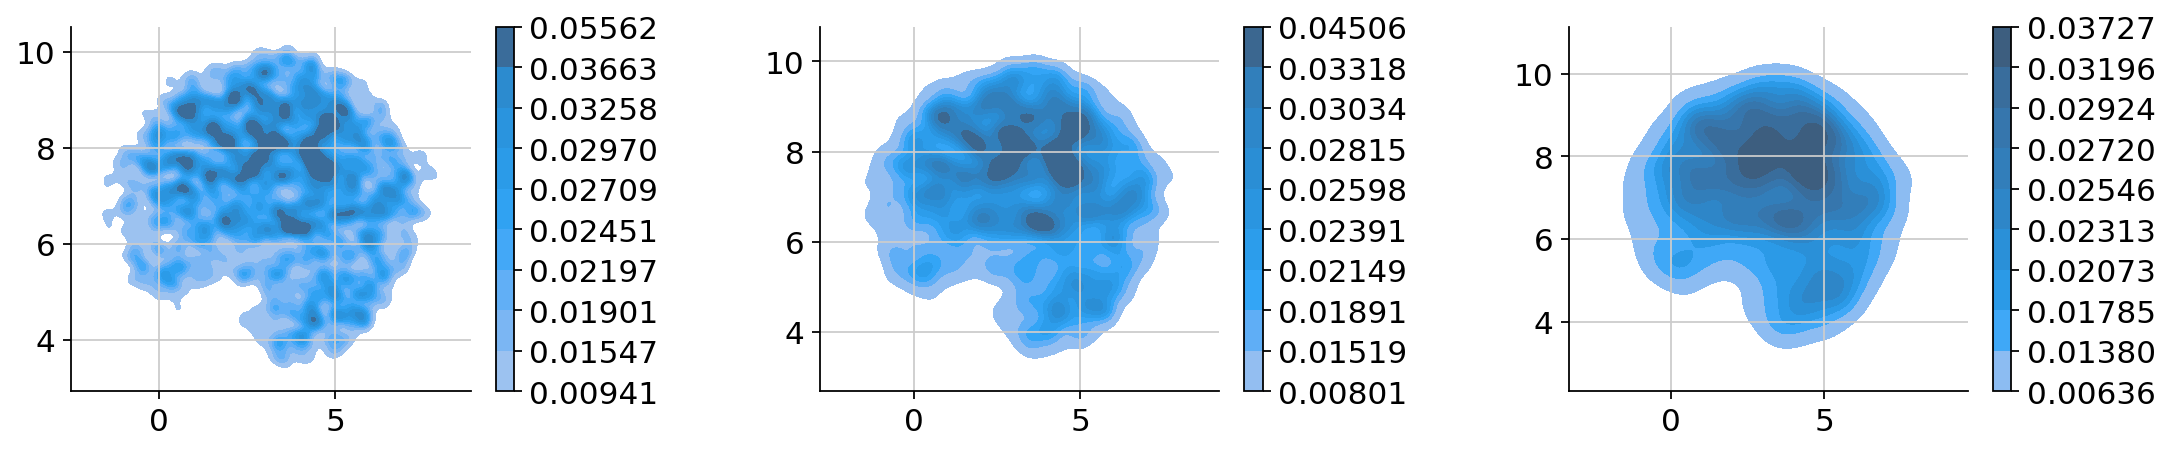

In [79]:
fig, axs = plt.subplots(1,3, figsize=(16,3), gridspec_kw={'wspace':0.5})

for i, bw in enumerate([0.3, 0.5, 0.8]):
    sns.kdeplot(x=umap_coords[:,0], y=umap_coords[:,1], fill=True, cbar=True, bw_adjust=bw, ax=axs[i])
    sns.despine(ax=axs[i])

## 

<font size=3 color='navy'>(Option 1) by **Mean** expression of NC cells</font>

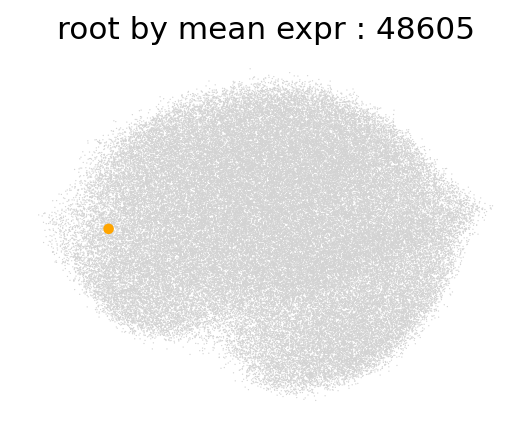

In [58]:
# mean expression of NC
mean_NC = control_cells.X.mean(axis=0)

# distance in expression space
MSE = np.sum((mul_adata_pure.X - mean_NC)**2, axis=1)
cb_root = np.argmin(MSE) 

# visualize
fig = sc.pl.umap(mul_adata_pure, show=False, return_fig=True)
sc.pl.umap(mul_adata_pure[cb_root], size=90, na_color='orange', ax=fig.gca(), title='root by mean expr : ' + str(cb_root))

<font size=3 color='orange'>(Option 2) by **Median** expression of NC cells</font>

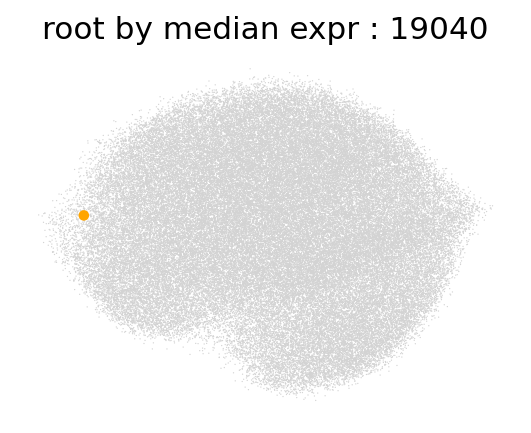

In [109]:
# median expression of NC
median_NC = np.median(control_cells.X.copy(), axis=0)

# distance in expression space
MSE = np.sum((mul_adata_pure.X - median_NC)**2, axis=1)
iroot = np.argmin(MSE)

cb_root = mul_adata_pure.obs_names[iroot]

# the location in umap
fig = sc.pl.umap(mul_adata_pure, show=False, return_fig=True)
sc.pl.umap(mul_adata_pure[cb_root], size=90, na_color='orange', ax=fig.gca(), title = 'root by median expr : ' + str(iroot))

<font size=3 color='BE3404'>(Option 3) by **Density** of NC cells</font>

In [94]:
kernel = stats.gaussian_kde(umap_coords.T)

den = kernel(umap_coords.T)

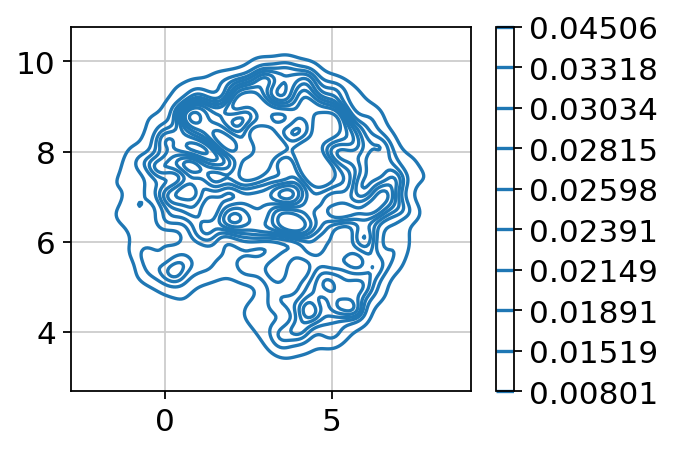

In [92]:
g = sns.kdeplot(x=umap_coords[:,0], y=umap_coords[:,1], cbar=True, bw_adjust=0.5)

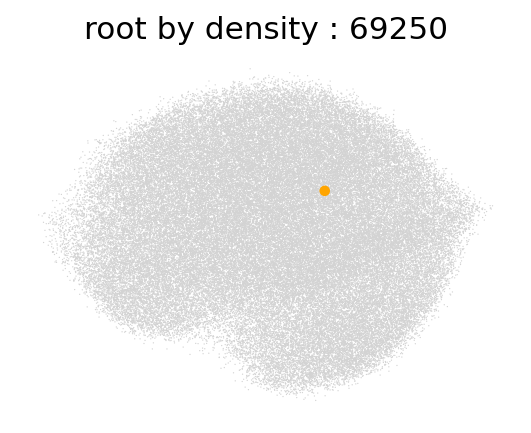

In [112]:
cb_root = control_cells.obs_names[np.argmax(den)]
iroot = np.where(mul_adata_pure.obs_names == cb_root)[0][0]

# the location in umap
fig = sc.pl.umap(mul_adata_pure, show=False, return_fig=True)
sc.pl.umap(mul_adata_pure[cb_root], size=90, na_color='orange', ax=fig.gca(), title = 'root by density : ' + str(iroot))

# **compute pseudo-time by iroot**

In [63]:
mul_adata_pure.uns['iroot'] = 48605 
cb_root = mul_adata_pure.obs_names[mul_adata_pure.uns['iroot']]

sc.tl.diffmap(mul_adata_pure, n_comps=10)
sc.tl.dpt(mul_adata_pure)

# split train/ test and discretize the dpt

In [118]:
from src import _pp_fun as pp
from importlib import reload

In [99]:
reload(pp)

<module 'src._pp_fun' from '/home/wergillius/Project/diffuse_differentiate/src/_pp_fun.py'>

In [101]:
pp.infer_knn_depth(mul_adata_pure)

mul_adata_pure.obs['discrete_time'] = mul_adata_pure.obs['dpt_pseudotime'].apply(pp.discrete_time)

pp.random_split(mul_adata_pure)

mul_adata_pure.write_h5ad("/home/wergillius/Project/diffuse_differentiate/data/Perturb_sci/d_preprocessed_Apr11.h5ad")

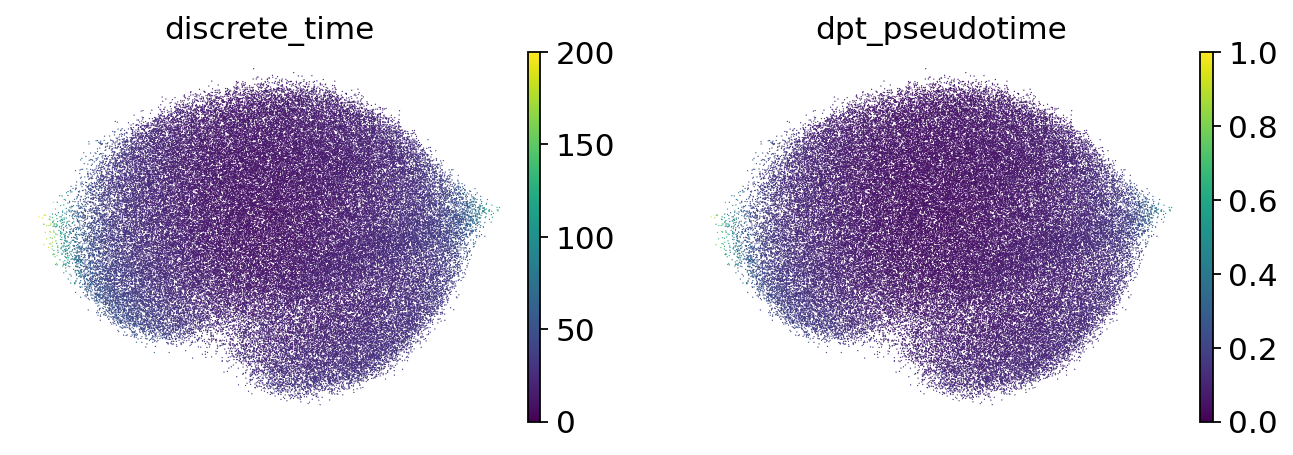

In [54]:
sc.pl.umap(mul_adata_pure, color=['discrete_time', 'dpt_pseudotime'])

# by density

In [114]:
ad_density = mul_adata_pure.copy()

In [115]:
ad_density.uns['iroot'] = 69250
cb_root = ad_density.obs_names[mul_adata_pure.uns['iroot']]

In [116]:
sc.tl.diffmap(ad_density, n_comps=10)
sc.tl.dpt(ad_density)

pp.infer_knn_depth(ad_density)
ad_density.obs['discrete_time'] = ad_density.obs['dpt_pseudotime'].apply(pp.discrete_time)

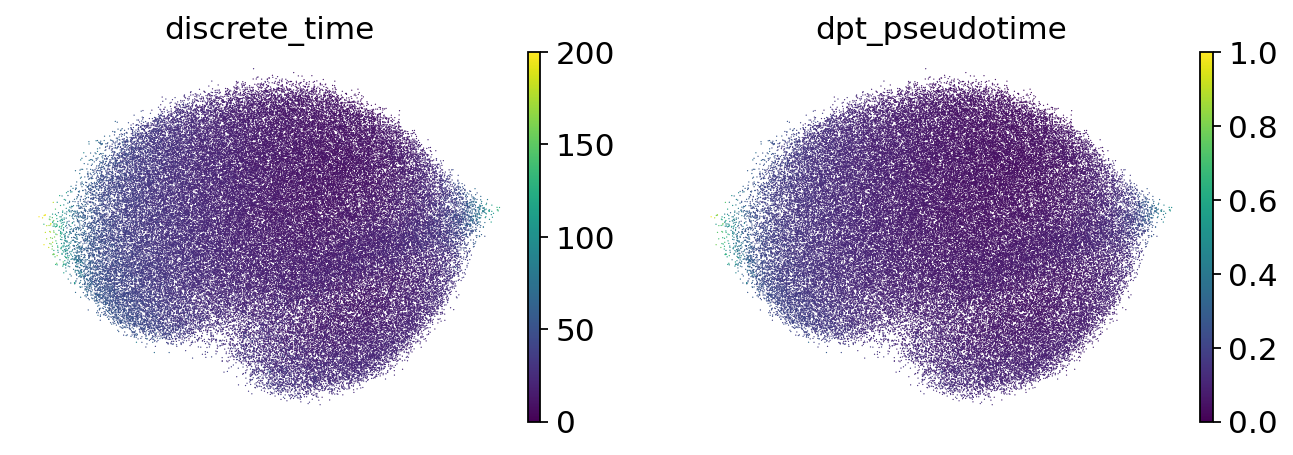

In [120]:
sc.pl.umap(ad_density, color=['discrete_time', 'dpt_pseudotime'])

In [121]:
ad_density.write_h5ad("/home/wergillius/Project/diffuse_differentiate/data/Perturb_sci/bydensity_Apr16.h5ad")

# **nascent count as unspliced and run scvelo**|

In [51]:
import warnings
warnings.filterwarnings("ignore")

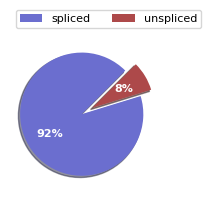

In [43]:
DenseRoot_ad = sc.read_h5ad("/home/wergillius/Project/diffuse_differentiate/data/Perturb_sci/bydensity_Apr16.h5ad")

# assign spliced and unspliced
DenseRoot_ad.layers['unspliced'] = DenseRoot_ad.layers['Count_nascent_tx']
DenseRoot_ad.layers['spliced'] =  DenseRoot_ad.layers['Count_whole_tx'] - DenseRoot_ad.layers['Count_nascent_tx']

scv.pl.proportions(DenseRoot_ad)

In [44]:
# some QC
scv.pp.filter_genes(DenseRoot_ad, min_shared_counts=20)
scv.pp.normalize_per_cell(DenseRoot_ad)

scv.pp.filter_genes_dispersion(DenseRoot_ad, n_top_genes=2000)
scv.pp.log1p(DenseRoot_ad)

Filtered out 1879 genes that are detected 20 counts (shared).
Extracted 2000 highly variable genes.


/var/tmp/pbs.90184.hpc-hn001/ipykernel_3179/2251090371.py:4: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  scv.pp.log1p(DenseRoot_ad)


In [47]:
# smoothing
scv.pp.moments(DenseRoot_ad, n_pcs=50, n_neighbors=50)

computing moments based on connectivities
    finished (0:00:25) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [49]:
scv.tl.velocity(DenseRoot_ad, mode='stochastic')

computing velocities
    finished (0:00:12) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


In [ ]:
scv.tl.velocity_graph(DenseRoot_ad, n_jobs=34)

computing velocity embedding
    finished (0:00:24) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


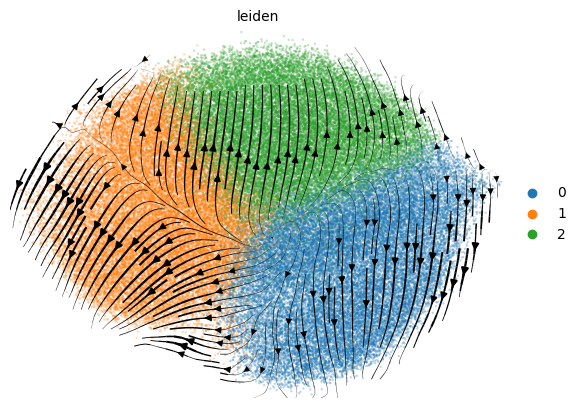

In [53]:
scv.pl.velocity_embedding_stream(DenseRoot_ad,
                                    color='leiden', 
                                    legend_loc='far right', 
                                    )

In [65]:
# replace X with Mean unspliced
X_orig = DenseRoot_ad.X.copy()
DenseRoot_ad.X = DenseRoot_ad.layers['Mu'].copy()

# recompute KNN
sc.tl.pca(DenseRoot_ad)
sc.pp.neighbors(DenseRoot_ad, n_neighbors=20)

# diffusion map
scv.tl.diffmap(DenseRoot_ad, n_comps=10)
scv.tl.dpt(DenseRoot_ad, n_dcs=10)

scv.tl.velocity_pseudotime(DenseRoot_ad, vkey='velocity', root_key=69250)

In [76]:
DenseRoot_ad.X = X_orig

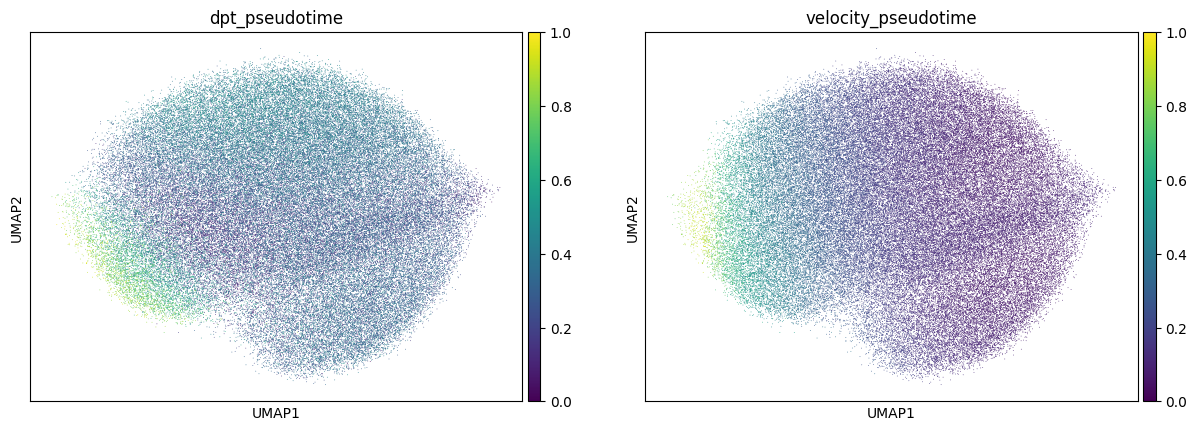

In [75]:
sc.pl.umap(DenseRoot_ad, color=['dpt_pseudotime', 'velocity_pseudotime'])

In [77]:
DenseRoot_ad.write_h5ad(os.path.join(PATH.data_dir, 'Perturb_sci/bydensity_Apr16.h5ad'))